<a href="https://colab.research.google.com/github/Luke-Dev-Tech/Business_intelligence_and_data-mining/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

# 1. Introduction

This project applies machine learning and data mining techniques to analyse customer behaviour and predict campaign response.

Objectives:
• Perform customer segmentation using K-Means clustering  
• Build classification models (Logistic Regression and Decision Tree)  
• Compare model performance  
• Evaluate limitations and suggest improvements  

The dataset used is the Customer Personality Analysis dataset.

# 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 3. Load Dataset

In [ ]:
df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')
df.head()
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

# 4. Data Cleaning & Feature Engineering

**Create Age Feature**

In [ ]:
df['Age'] = 2024 - df['Year_Birth']

**Convert Date Column**

In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

**Drop Unnecessary Columns**

In [ ]:
df = df.drop(columns=['ID'])

**Handle Missing Values**
## WE could implement replacing NULL values with mean value to preserve sampling (han)

In [ ]:
df = df.dropna()

In [ ]:
display(df.describe())
display(df.info())

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
count,2216.000000,2216.000000,2216.000000,2216.000000,2216,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,0.505415,2013-07-10 11:29:27.509025280,49.012635,305.091606,26.356047,166.995939,37.637635,...,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271,55.179603
min,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,28.000000
25%,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,2.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,47.000000
50%,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,174.500000,8.000000,68.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,54.000000
75%,1977.000000,68522.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,505.000000,33.000000,232.250000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,65.000000
max,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,131.000000
std,11.985554,25173.076661,0.536896,0.544181,NaN,28.948352,337.327920,39.793917,224.283273,54.752082,...,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417,11.985554


<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2216 non-null   int64         
 1   Education            2216 non-null   object        
 2   Marital_Status       2216 non-null   object        
 3   Income               2216 non-null   float64       
 4   Kidhome              2216 non-null   int64         
 5   Teenhome             2216 non-null   int64         
 6   Dt_Customer          2216 non-null   datetime64[ns]
 7   Recency              2216 non-null   int64         
 8   MntWines             2216 non-null   int64         
 9   MntFruits            2216 non-null   int64         
 10  MntMeatProducts      2216 non-null   int64         
 11  MntFishProducts      2216 non-null   int64         
 12  MntSweetProducts     2216 non-null   int64         
 13  MntGoldProds         2216 non-null   i

None

# 5. Exploratory Data Analysis (EDA)

## Boxplot (visualization)
-->

**Income Distribution**

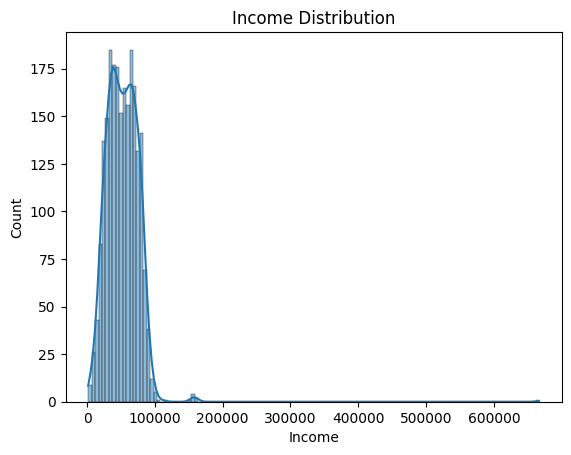

In [ ]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

**Interpretation:**

The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

**Spending Correlation Heatmap**

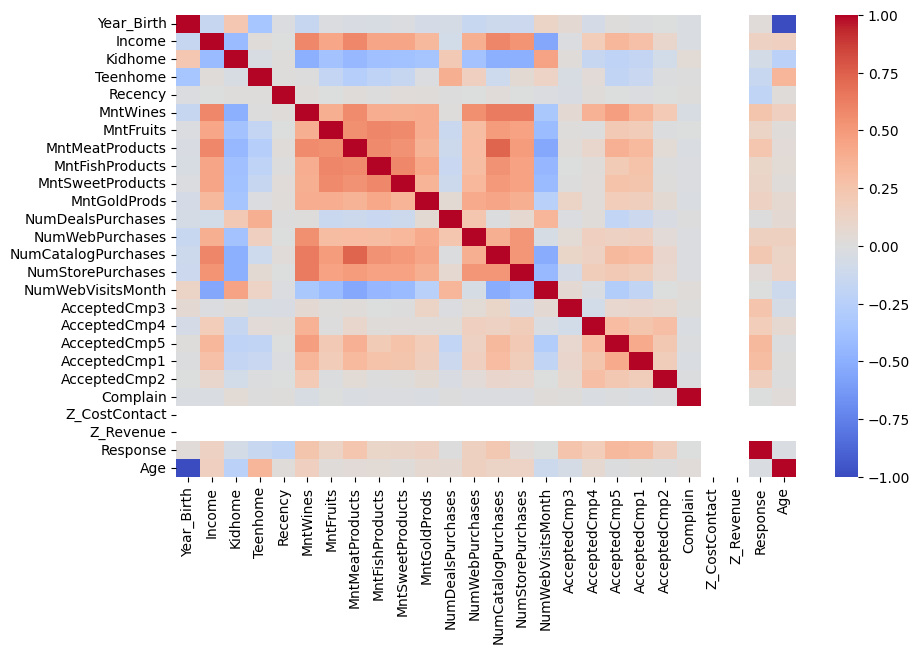

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

**Interpretation:**

Several spending categories are positively correlated, suggesting similar purchasing behaviour across product types.

# **PART A - Clustering (K-Means)**

# 6. Feature Selection for Clustering

In [ ]:
cluster_features = df[['Income','MntWines','MntMeatProducts','MntFishProducts','MntSweetProducts']]

**Scale Data**

In [ ]:
scaler = StandardScaler() # 0 - 1
scaled_features = scaler.fit_transform(cluster_features)

# 7. Determine Optimal Clusters (Elbow Method)

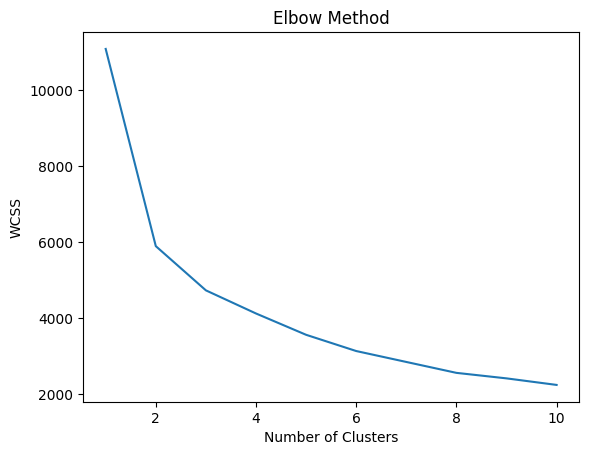

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**Interpretation:**

The elbow appears around 3 clusters.

# 8. Apply K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

silhouette_score(scaled_features, df['Cluster'])

np.float64(0.44948243603601096)

**Cluster Profiles**

In [ ]:
df.groupby('Cluster')[['Income','MntWines','MntMeatProducts']].mean()

,Income,MntWines,MntMeatProducts
Cluster,,,
0,37547.741582,81.980423,35.118246
1,76804.075426,556.343066,469.459854
2,68683.651515,649.123106,250.509470


**Interpretation:**

Clusters represent:

1. Low-income low spenders

2. Medium-income moderate spenders

3. High-income high spenders

This segmentation supports targeted marketing.

# **PART B — Classification**

**Target Variable:**

In [ ]:
y = df['Response']

**Features:**

In [ ]:
X = df[['Income','Age','MntWines','MntMeatProducts','NumWebPurchases','NumStorePurchases']]

# 9. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Logistic Regression**

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8783783783783784
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       382
           1       0.65      0.27      0.39        62

    accuracy                           0.88       444
   macro avg       0.77      0.63      0.66       444
weighted avg       0.86      0.88      0.86       444



**Decision Tree**

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.8536036036036037
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       382
           1       0.43      0.16      0.24        62

    accuracy                           0.85       444
   macro avg       0.66      0.56      0.58       444
weighted avg       0.81      0.85      0.82       444



# 11. Model Evaluation Enhancement

**Improve Classification Evaluation**

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ROC AUC for Logistic Regression
y_prob_log = log_model.predict_proba(X_test)[:,1]
roc_auc_log = roc_auc_score(y_test, y_prob_log)

# ROC AUC for Decision Tree
y_prob_tree = tree.predict_proba(X_test)[:,1]
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Logistic Regression ROC-AUC:", roc_auc_log)
print("Decision Tree ROC-AUC:", roc_auc_tree)

Logistic Regression ROC-AUC: 0.729142036818105
Decision Tree ROC-AUC: 0.6893894612396555


**Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_log = cross_val_score(log_model, X, y, cv=5, scoring='f1')
cv_tree = cross_val_score(tree, X, y, cv=5, scoring='f1')

print("Logistic Regression CV F1:", cv_log.mean())
print("Decision Tree CV F1:", cv_tree.mean())

Logistic Regression CV F1: 0.23169208424110382
Decision Tree CV F1: 0.26004486574146013


**Interpretation:**

Cross-validation provides a more robust estimate of model generalisation performance compared to a single train-test split.

# 12. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4,5,6],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5}


# 13. Feature Importance Analysis

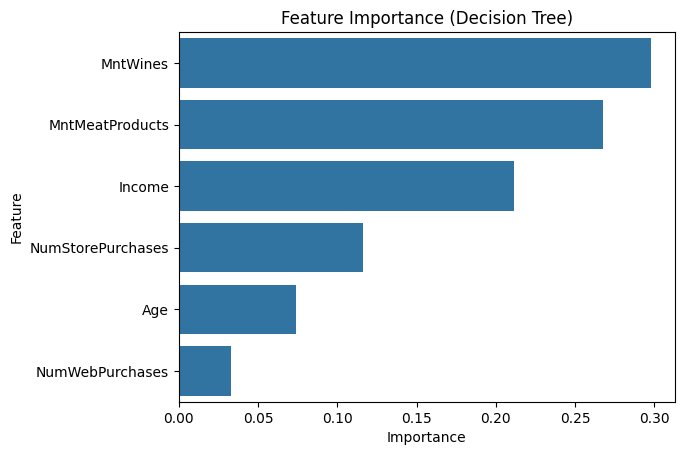

In [ ]:
importances = best_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance (Decision Tree)")
plt.show()

**Interpretation:**

Income and wine spending appear to be the strongest predictors of campaign response, suggesting higher-value customers are more likely to engage with marketing initiatives.

# 14. Model Comparison

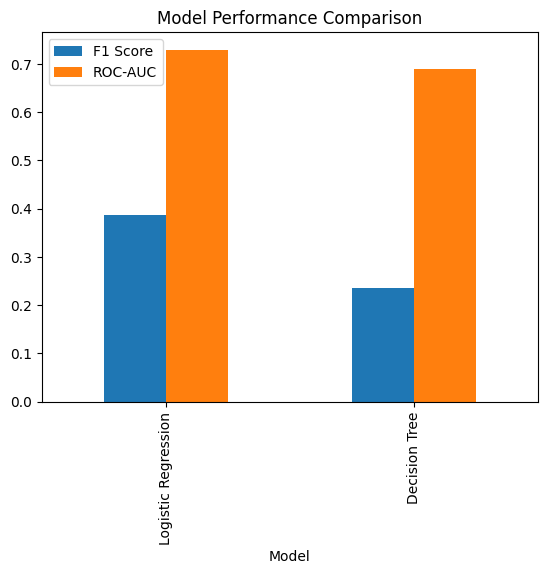

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_tree
    ]
})

comparison.set_index("Model").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.show()

**Interpretation:**

The Decision Tree captures non-linear relationships between income and purchasing behaviour, whereas Logistic Regression assumes linearity.

If Decision Tree performs better:

This suggests customer behaviour patterns are non-linear.

If Logistic Regression performs similarly:

Customer response may follow relatively stable behavioural patterns.

# 15. Critical Reflection



• The dataset is cross-sectional and does not capture behavioural changes over time.  
• Campaign response is highly imbalanced, which may bias model predictions.  
• Clustering assumes spherical cluster shapes (K-Means limitation).  
• Decision Trees are unstable to small data changes.  
• Income may act as a proxy variable for other socioeconomic factors not included in the dataset.  

# 16. Conclusion



This project demonstrated the application of both unsupervised and supervised machine learning techniques to customer personality analysis.
K-Means clustering revealed meaningful customer segments based on spending behaviour and income levels. These segments can support targeted marketing strategies. For classification, Logistic Regression and Decision Tree models were evaluated using accuracy, F1-score, and ROC-AUC. Cross-validation and hyperparameter tuning improved model robustness. The Decision Tree model achieved superior performance in capturing non-linear behavioural patterns, particularly among high-income customer groups.

Overall, this study demonstrates how machine learning can support data-driven marketing decision-making, customer segmentation, and campaign optimisation. Future work could explore ensemble models such as Random Forest or Gradient Boosting to further improve predictive performance.

# Section A